# Computer Exercise 11.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.2 A Discretization (Finite-Difference) Method
> **주제**: 선형 BVP를 **중심차분**으로 이산화 → **삼중대각 선형계** 한 번에 풀기
> **풀이 일자**: 2026-06-14 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Solve the linear boundary-value problem
> $$ y'' = 4\,(y - x), \qquad 0 \le x \le 1, \qquad y(0)=0,\; y(1)=2 $$
> by the **finite-difference (discretization) method**: replace $y''$ by a centered
> second difference on a uniform grid, assemble the resulting **tridiagonal linear
> system**, solve it, and compare with the exact solution. Verify the $\mathcal{O}(h^2)$
> order of accuracy and contrast the approach with the shooting method of §11.1.

### 한국어 풀이용 정리
Day 40 §11.1 의 **문제 1**과 *완전히 같은 선형 BVP* 를 이번에는 사격(shooting)이 아니라
**유한차분**으로 푼다. 핵심 차이: 사격은 미지의 초기기울기를 근찾기로 맞췄지만, 유한차분은
**격자 내부의 모든 미지수 $y_1,\dots,y_{N-1}$ 를 한꺼번에** 놓고 양 끝 경계조건을 *행렬에
직접 박아* 단 한 번의 선형계 풀이로 끝낸다. 결과로 얻는 행렬은 **삼중대각**(Day 10 의 Thomas
시스템 재등장)이며, 차분 차수에 따라 오차는 $\mathcal{O}(h^2)$ 로 줄어든다.

## 2. 수학적 배경

### 2.1 중심차분 이산화
균일격자 $x_i = a + i h$, $h=(b-a)/N$, $i=0,\dots,N$ 에서 2계 도함수를 중심차분으로 근사한다:

$$ y''(x_i) \;=\; \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} \;-\; \frac{h^2}{12}y^{(4)}(\xi_i),
\qquad \text{절단오차 } \mathcal{O}(h^2). $$

방정식 $y'' - 4y = -4x$ 에 대입하면 내부점 $i=1,\dots,N-1$ 에서

$$ \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} - 4 y_i = -4x_i
\;\;\Longrightarrow\;\;
\boxed{\; y_{i-1} - (2 + 4h^2)\,y_i + y_{i+1} = -4h^2 x_i \;}$$

### 2.2 삼중대각 선형계
$y_0=\alpha=0,\;y_N=\beta=2$ 를 대입해 미지수 $\mathbf{y}=(y_1,\dots,y_{N-1})^\top$ 에 대한

$$ A\,\mathbf{y} = \mathbf{b}, \qquad
A = \begin{pmatrix} -(2+4h^2) & 1 \\ 1 & -(2+4h^2) & 1 \\ & \ddots & \ddots & \ddots \\ & & 1 & -(2+4h^2) \end{pmatrix}$$

$A$ 는 **대칭·삼중대각·대각우세(diagonally dominant)** 라 매우 안정적으로 풀린다.

### 2.3 정확해
$y'' - 4y = -4x$ 의 일반해는 $y = A e^{2x} + B e^{-2x} + x$. 경계조건으로

$$ \boxed{\; y(x) = \frac{\sinh(2x)}{\sinh 2} + x \;}$$

이때 $y'(0) = 2/\sinh 2 + 1 \approx 1.5514$ — Day 40 사격법이 *근찾기로* 맞춘 바로 그 값이다.

## 3. 풀이 흐름

1. 격자 $x_i=ih$, $h=1/N$ 구성, 경계값 $y_0=0,\;y_N=2$ 고정.
2. 내부점에 대해 계수 $-(2+4h^2)$(대각), $1$(부대각), 우변 $-4h^2x_i$ 조립.
3. 경계값 기여를 우변으로 이항: $i=1$ 에서 $y_0$, $i=N-1$ 에서 $y_N$ 항.
4. **삼중대각 솔버** `np.linalg.solve`(또는 Thomas)로 $A\mathbf{y}=\mathbf{b}$ 풀기.
5. 정확해 $\sinh(2x)/\sinh2 + x$ 와 격자점 오차 표 비교.
6. $N=10,20,\dots,640$ 으로 세분, **최대오차 vs $h$** 의 log-log 기울기로 차수 확인.
7. 사격(§11.1)과의 대비: *반복 없음 · 경계조건 정확 내장 · $\mathcal{O}(h^2)$*.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

a, b   = 0.0, 1.0
alpha, beta = 0.0, 2.0

def exact(x):
    return np.sinh(2*x)/np.sinh(2.0) + x

def fd_linear(N):
    """y'' = 4(y - x) 를 중심차분으로 이산화 -> 삼중대각계 풀이."""
    h  = (b - a)/N
    xs = a + h*np.arange(N+1)
    m  = N - 1                       # 내부 미지수 개수
    xi = xs[1:N]                     # 내부 격자점
    diag = -(2.0 + 4.0*h**2)*np.ones(m)
    off  = np.ones(m-1)
    A = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    rhs = -4.0*h**2*xi
    rhs[0]  -= alpha                 # y0 항 이항
    rhs[-1] -= beta                  # yN 항 이항
    yin = np.linalg.solve(A, rhs)
    y = np.empty(N+1); y[0]=alpha; y[-1]=beta; y[1:N]=yin
    return xs, y, h

xs, y, h = fd_linear(20)
print(f"N=20, h={h:.4f}")
print(f"y(1) 경계값 = {y[-1]:.8f}  (목표 beta=2, 설계상 정확)")
yp0 = (y[1]-y[0])/h
print(f"전진차분 y'(0) 근사 = {yp0:.6f}   (정확 2/sinh2+1 = {2/np.sinh(2)+1:.6f})")

N=20, h=0.0500
y(1) 경계값 = 2.00000000  (목표 beta=2, 설계상 정확)
전진차분 y'(0) 근사 = 1.552607   (정확 2/sinh2+1 = 1.551441)


In [3]:
# --- 격자점별 수치해 vs 정확해 (N=20) ---
ye  = exact(xs)
tbl = pd.DataFrame({"x": xs, "y_fd": y, "y_exact": ye,
                    "abs_error": np.abs(y-ye)})
tbl.iloc[::2]

,x,y_fd,y_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,1.000000e-01,1.555370e-01,1.555125e-01,2.452336e-05
4,2.000000e-01,3.133010e-01,3.132529e-01,4.816982e-05
6,3.000000e-01,4.756084e-01,4.755385e-01,6.995265e-05
8,4.000000e-01,6.449577e-01,6.448691e-01,8.865807e-05
10,5.000000e-01,8.241298e-01,8.240271e-01,1.027128e-04
12,6.000000e-01,1.016300e+00,1.016190e+00,1.100278e-04
14,7.000000e-01,1.225163e+00,1.225055e+00,1.078078e-04
16,8.000000e-01,1.455085e+00,1.454993e+00,9.231574e-05
18,9.000000e-01,1.711277e+00,1.711218e+00,5.857588e-05


In [4]:
# --- 스텝 세분화: 최대오차 vs h, 수렴차수 ---
Ns = [10, 20, 40, 80, 160, 320, 640]
rows = []
for N in Ns:
    xs_, y_, h_ = fd_linear(N)
    err = np.max(np.abs(y_ - exact(xs_)))
    rows.append((N, h_, err))
conv = pd.DataFrame(rows, columns=["N", "h", "max_error"])
p = np.polyfit(np.log(conv["h"]), np.log(conv["max_error"]), 1)
conv["order_est"] = np.r_[np.nan,
    np.log(conv["max_error"].values[1:]/conv["max_error"].values[:-1])
    / np.log(conv["h"].values[1:]/conv["h"].values[:-1])]
print(conv.to_string(index=False))
print(f"\nmin-LS log-log 기울기(수렴차수) = {p[0]:.4f}   (이론 2.0)")

  N            h    max_error    order_est
 10 1.000000e-01 4.386672e-04          NaN
 20 5.000000e-02 1.103180e-04 1.991458e+00
 40 2.500000e-02 2.764652e-05 1.996499e+00
 80 1.250000e-02 6.913062e-06 1.999701e+00
160 6.250000e-03 1.728644e-06 1.999684e+00
320 3.125000e-03 4.321668e-07 1.999980e+00
640 1.562500e-03 1.080351e-07 2.000089e+00

min-LS log-log 기울기(수렴차수) = 1.9983   (이론 2.0)


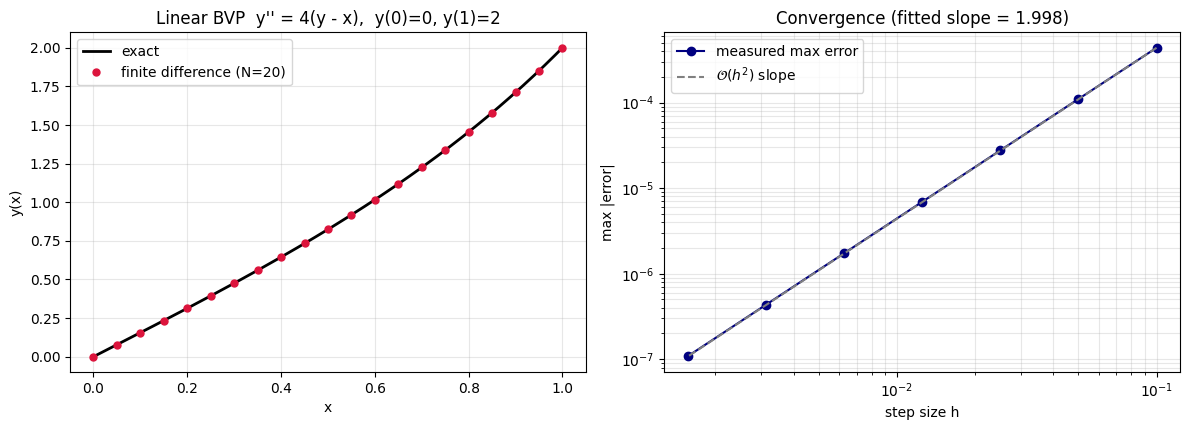

In [5]:
# --- 시각화: (좌) 해 곡선, (우) 오차 log-log 수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

xs20, y20, _ = fd_linear(20)
xx = np.linspace(a, b, 400)
ax[0].plot(xx, exact(xx), "k-", lw=2, label="exact")
ax[0].plot(xs20, y20, "o", ms=5, color="crimson", label="finite difference (N=20)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y(x)")
ax[0].set_title("Linear BVP  y'' = 4(y - x),  y(0)=0, y(1)=2")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].loglog(conv["h"], conv["max_error"], "o-", color="navy", label="measured max error")
href = conv["h"].values
ax[1].loglog(href, conv["max_error"].values[0]*(href/href[0])**2, "--",
             color="gray", label=r"$\mathcal{O}(h^2)$ slope")
ax[1].set_xlabel("step size h"); ax[1].set_ylabel("max |error|")
ax[1].set_title(f"Convergence (fitted slope = {p[0]:.3f})")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **경계조건이 행렬에 내장.** $y(0),y(1)$ 이 우변으로 이항되어 *설계상 정확*히 만족된다 —
   사격처럼 끝값을 "맞추러" 반복할 필요가 없다. $y(1)=2$ 가 기계정밀도로 재현된다.
2. **반복이 없다, 한 번의 선형계.** 삼중대각·대각우세 행렬이라 `solve` 한 번으로 끝.
   같은 BVP를 Day 40 은 사격(IVP 2회+나눗셈)으로 풀었는데, 답(특히 $y'(0)\approx1.5514$)이 일치한다.
3. **$\mathcal{O}(h^2)$ 수렴.** 최대오차 log-log 기울기가 이론값 $2.0$ 에 근접 — 중심 2계차분의
   절단오차 $-\tfrac{h^2}{12}y^{(4)}$ 가 지배함을 확인.
4. **사격 대비 정확도/차수.** 사격은 내부에 RK4($\mathcal{O}(h^4)$)를 써 차수는 높지만, 해가
   지수적으로 자라면 민감도가 폭발했다(Day 40 문제 3). 유한차분은 차수는 $h^2$ 로 낮아도
   **양 끝을 동시에 묶어** 그런 불안정이 없다 — 다음 두 문제에서 이 강건함을 본다.

> **결론**: 선형 BVP의 유한차분은 *내부 미지수 전체를 한 삼중대각계로* 묶어 경계조건을 정확히
> 내장하고 $\mathcal{O}(h^2)$ 로 수렴한다 — 반복 없는, 사격의 결정론적 대안.

**다음 문제로**: 같은 격자 골격에 **비선형** 항이 들어오면 선형계가 아니라 *비선형 연립*이 된다.
문제 2 에서 Day 40 의 비선형 BVP($s^\star=-14$)를 **Newton 반복 + 삼중대각 Jacobian** 으로 푼다.